# Intro

In this notebook we will be joining the features in a 300 km radius for DC data and then also joining on the other datasets while we are at it. The goal is to make a dataset of stations with applicable data for their surrounding environment.

In [2]:
from google.colab import drive
drive.mount('/content/drive')
import os, shutil, subprocess

WORK_DIR = '/content/drive/MyDrive/DL_Project'
os.chdir(WORK_DIR)
print('cwd:', os.getcwd())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
cwd: /content/drive/MyDrive/DL_Project


In [2]:
import pandas as pd
import geopandas as gpd

# Import

First we gotta import the data. Lets first do our station dataset and then get the shape file.

In [3]:
# read in cabi data
cabi = pd.read_parquet('data/cabi_combined_data.parquet')

In [4]:
built_env = gpd.read_file("data/built_environment_indicators/Data_Hacktoberfest_Built_Environment_Final_Data.shp")
print(built_env.crs)
print(built_env.head())
print(built_env.columns.tolist())

EPSG:26985
  TRACTCE        GEOID  m1_1_schoo  m1_2_quali  m1_3_playg  m1_4_cross  \
0  009807  11001009807    0.999899    0.000000    0.515735    0.152876   
1  009802  11001009802    0.999901    0.000000    0.999901    0.261362   
2  009803  11001009803    0.999894    0.000000    0.171991    0.088983   
3  002002  11001002002    0.999899    0.999899    0.999869    0.105417   
4  002101  11001002101    0.999901    0.999766    0.895557    0.222397   

   m1_5_safe_  m1_6_libra  m1_7_wirel  m1_8_broad  ...    d1_raw    d2_raw  \
0    0.000000    0.813928    0.999899    0.645201  ...  0.372166  0.019417   
1    0.000000    0.648101    0.999901    0.683710  ...  0.530679  0.014563   
2    0.699218    0.927700    0.999894    0.772940  ...  0.389224  0.184466   
3    0.397312    0.546744    0.999899    0.889110  ...  0.561015  0.213592   
4    0.999901    0.278853    0.999901    0.831951  ...  0.684580  0.092233   

     d3_raw    d4_raw    d5_raw    d6_raw    d7_raw    d8_raw    d9_raw  \


# Filter Cabi
Now lets filter the capital bikeshare dataset down to what it needs to be. We specifically just want information on all stations

In [5]:
print(cabi.columns)
# stations can have mutliple rows, we really just want one lon / lat for each station. I just take the first
stations = cabi[['start_station_id', 'start_station_name', 'start_lat', 'start_lng']].groupby('start_station_id').head(1).copy()
# now lets rename
stations.rename(columns ={'start_station_id' : 'station_id', 
                            'start_station_name' : 'station_name',
                            'start_lat' : "latitude",
                            "start_lng" : 'longitude'}, inplace=True)

Index(['ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual', '_source_zip', '_source_file'],
      dtype='object')


In [6]:
# just double checking things here
print(stations.columns)
print(stations.head(5))
print(stations.shape)
print(stations.station_id.nunique())

Index(['station_id', 'station_name', 'latitude', 'longitude'], dtype='object')
   station_id                                       station_name   latitude  \
0     31087.0                            Monroe Ave & Leslie Ave  38.820932   
1     31283.0                                     14th & L St NW  38.903658   
3     31518.0                        New York Ave & Hecht Ave NE  38.915604   
4     32608.0  Falls Church City Hall / Park Ave & Little Fal...  38.885434   
6     31104.0                        Adams Mill & Columbia Rd NW  38.922925   

   longitude  
0 -77.053096  
1 -77.031737  
3 -76.983683  
4 -77.173605  
6 -77.042581  
(862, 4)
862


# Join data

In [7]:
# convert stations to a geopandas dataframe

stations_gpd = gpd.GeoDataFrame(
    stations,
    geometry=gpd.points_from_xy(stations.longitude, stations.latitude),
    crs="EPSG:4326"  
).to_crs("EPSG:26985")

In [8]:
stations_joined = gpd.sjoin(stations_gpd, built_env, how="left", predicate="within")

In [9]:
# lets count and check

stations_joined.groupby('station_id')['m1_1_schoo'].sum().reset_index()

,station_id,m1_1_schoo
0,22907.0,0.817486
1,30200.0,0.999894
2,30201.0,0.999894
3,31000.0,0.000000
4,31001.0,0.000000
...,...,...
857,33201.0,0.999900
858,33202.0,0.999899
859,33203.0,0.991277
860,33204.0,0.999894


/tmp/ipykernel_25670/2488103942.py:8: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


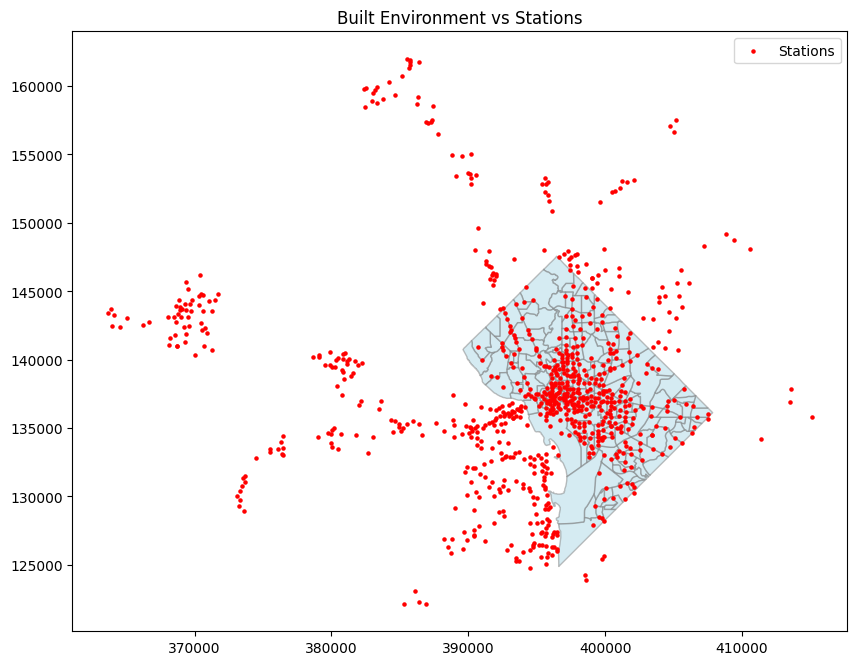

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

built_env.plot(ax=ax, color="lightblue", edgecolor="gray", alpha=0.5, label="Built Env")
stations_gpd.plot(ax=ax, color="red", markersize=5, label="Stations")

plt.legend()
plt.title("Built Environment vs Stations")
plt.show()

In [11]:
# convert back to a normal pandas
stations_built_env = stations_joined.drop(columns="geometry").reset_index(drop=True)
print(stations_built_env.head(10))
print(stations_built_env.shape)

   station_id                                       station_name   latitude  \
0     31087.0                            Monroe Ave & Leslie Ave  38.820932   
1     31283.0                                     14th & L St NW  38.903658   
2     31518.0                        New York Ave & Hecht Ave NE  38.915604   
3     32608.0  Falls Church City Hall / Park Ave & Little Fal...  38.885434   
4     31104.0                        Adams Mill & Columbia Rd NW  38.922925   
5     31105.0                               14th & Harvard St NW  38.926800   
6     31606.0                      Potomac & Pennsylvania Ave SE  38.880300   
7     31607.0                                     13th & E St SE  38.882921   
8     31641.0                      2nd St & Massachusetts Ave NE  38.894972   
9     31310.0                      Connecticut & Nebraska Ave NW  38.955075   

   longitude  index_right TRACTCE        GEOID  m1_1_schoo  m1_2_quali  \
0 -77.053096          NaN     NaN          NaN         N

In [12]:
stations_built_env.to_parquet("data/stations_with_buil_env.parquet", index=False, engine="pyarrow", compression="snappy")

# Join Census Information
This will be another overlap join if we can get it

In [13]:
# read in data
census = gpd.read_file("data/census_tract_demographics.gpkg")
census = census.to_crs("EPSG:26985")

/tmp/ipykernel_25670/1768852046.py:8: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


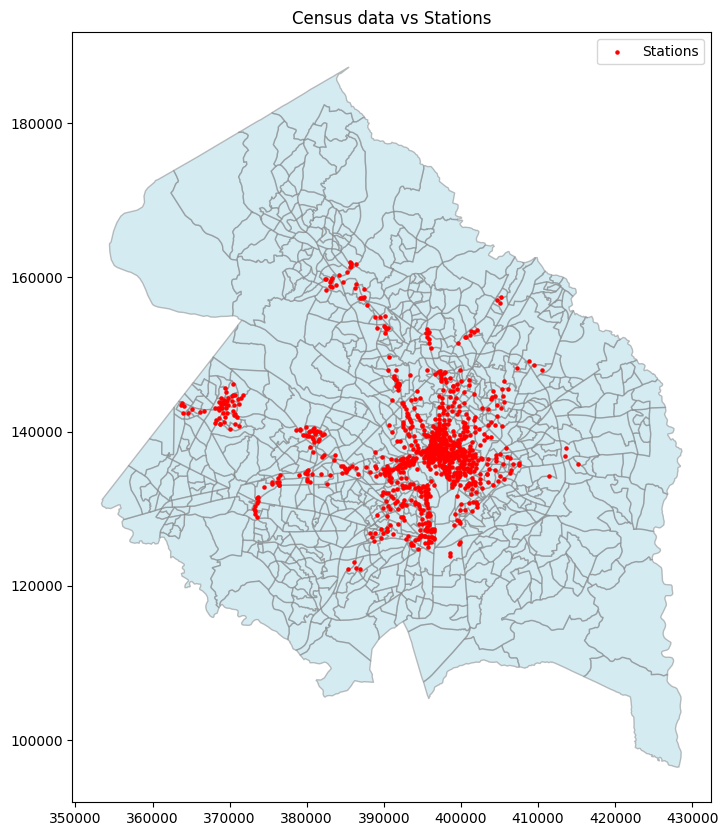

In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

census.plot(ax=ax, color="lightblue", edgecolor="gray", alpha=0.5, label="Built Env")
stations_gpd.plot(ax=ax, color="red", markersize=5, label="Stations")

plt.legend()
plt.title("Census data vs Stations")
plt.show()

In [15]:
# lets now join it
stations_joined = stations_joined.drop(columns="index_right")
stations_with_census = gpd.sjoin(stations_joined, census, how="left", predicate="within")

In [16]:
stations_with_census

,station_id,station_name,latitude,longitude,geometry,TRACTCE_left,GEOID_left,m1_1_schoo,m1_2_quali,m1_3_playg,...,pop_maleE,pop_maleM,pop_femaleE,pop_femaleM,median_ageE,median_ageM,median_hh_incomeE,median_hh_incomeM,year,state
0,31087.0,Monroe Ave & Leslie Ave,38.820932,-77.053096,POINT (395389.143 128129.52),NaN,NaN,NaN,NaN,NaN,...,1870.0,234.0,1881.0,193.0,35.8,1.0,199444.0,32558.0,2024.0,VA
1,31283.0,14th & L St NW,38.903658,-77.031737,POINT (397247.151 137311.847),010100,11001010100,0.999902,0.619431,0.118688,...,1203.0,258.0,1388.0,288.0,34.5,0.7,112670.0,38301.0,2024.0,DC
3,31518.0,New York Ave & Hecht Ave NE,38.915604,-76.983683,POINT (401415.09 138637.599),008803,11001008803,0.999902,0.307632,0.160133,...,2362.0,376.0,2720.0,379.0,32.3,2.7,102585.0,20931.0,2024.0,DC
4,32608.0,Falls Church City Hall / Park Ave & Little Fal...,38.885434,-77.173605,POINT (384937.765 135302.683),NaN,NaN,NaN,NaN,NaN,...,1926.0,231.0,1733.0,190.0,41.6,4.9,204183.0,26759.0,2024.0,VA
6,31104.0,Adams Mill & Columbia Rd NW,38.922925,-77.042581,POINT (396307.547 139451.027),003901,11001003901,0.999905,0.000000,0.999905,...,1137.0,201.0,1597.0,503.0,34.5,5.4,134922.0,57867.0,2024.0,DC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20122679,33202.0,27th St & Woodley Rd NW,38.925764,-77.055113,POINT (395221.012 139766.761),000501,11001000501,0.999899,0.130074,0.141519,...,1574.0,349.0,2036.0,419.0,38.5,4.1,110774.0,16937.0,2024.0,DC
20135184,33201.0,Kansas Ave & Blair Rd NW,38.962406,-77.010476,POINT (399092.067 143833.004),009505,11001009505,0.999900,0.151707,0.846429,...,1730.0,358.0,2763.0,494.0,33.8,4.0,95078.0,31875.0,2024.0,DC
20148509,33203.0,Howard Rd & Suitland Pkwy SE,38.865149,-77.001045,POINT (399909.308 133036.573),007401,11001007401,0.991277,0.000000,0.481516,...,344.0,118.0,905.0,342.0,38.9,13.7,31862.0,14511.0,2024.0,DC
20447484,33204.0,15th & Chapin St NW,38.921468,-77.035244,POINT (396943.719 139289.016),003701,11001003701,0.999894,0.000000,0.999894,...,1282.0,170.0,1226.0,189.0,34.8,1.5,134508.0,22367.0,2024.0,DC


# Wmata Bikeshed
This is inspired from the following map: https://www.wmata.com/initiatives/pedshed-and-bikeshed-atlas/. It includes data on areas with low stress biking and the total bikeshed. These represent reasonable 3 mile traveling by bike from the metro along suitable bike routes, as well as low stress options.

In [17]:
low_stress_bikeshed = gpd.read_file("data/Pedsheds_and_Bikesheds_Shapefiles/Low_Stress_Bikesheds.shp")
low_stress_bikeshed = low_stress_bikeshed.to_crs("EPSG:26985")
total_bikeshed = gpd.read_file("data/Pedsheds_and_Bikesheds_Shapefiles/Total_Bikesheds.shp")
total_bikeshed = total_bikeshed.to_crs("EPSG:26985")

In [18]:
low_stress_bikeshed.head(5)

,Name,SqMi,householdt,employees_,Ridership,StationCod,Shape_Leng,Shape_Area,geometry
0,Herndon,0.077182,0.0,339.0,753.0,N08,2454.136611,3.310323e+05,"POLYGON ((366942.105 142906.059, 366947.105 14..."
1,Reston Town Center,0.150758,0.0,0.0,717.0,N07,4256.882909,6.466173e+05,"POLYGON ((368722.105 143266.059, 368742.105 14..."
2,Wiehle-Reston East,0.347003,205.0,2733.0,1590.0,N06,7153.441701,1.487994e+06,"POLYGON ((370022.105 142471.059, 370102.105 14..."
3,Franconia-Springfield,0.285348,333.0,114.0,3001.0,J03,6453.925447,1.217555e+06,"POLYGON ((384537.109 122566.055, 384542.109 12..."
4,Van Dorn Street,0.008306,0.0,0.0,1334.0,J02,801.121863,3.547410e+04,"POLYGON ((388772.11 125931.056, 388847.11 1258..."


In [19]:
total_bikeshed.head(5)

,Name,HS_sqmi,HS_HH,HS_Emp,Ridership,StationCod,Shape_Leng,Shape_Area,geometry
0,Branch Ave,2.539084,3504,3944,2545.0,F11,33346.993408,1.084988e+07,"POLYGON ((407876.922 129418.864, 407920.847 12..."
1,Braddock Road,9.883319,44012,90921,2089.0,C12,51464.194550,4.223387e+07,"POLYGON ((395573.906 131745.929, 395587.4 1317..."
2,King St-Old Town,10.663951,44630,85051,3545.0,C13,50043.814219,4.556530e+07,"MULTIPOLYGON (((391767.296 129790.159, 391770...."
3,Eisenhower Ave,7.908438,33139,77348,994.0,C14,45798.040141,3.378804e+07,"POLYGON ((394685.645 129852.978, 394742.834 12..."
4,Huntington,7.506462,17324,8549,3045.0,C15,47026.282919,3.204479e+07,"POLYGON ((395336.205 122318.121, 395225.472 12..."


/tmp/ipykernel_25670/3329595724.py:8: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


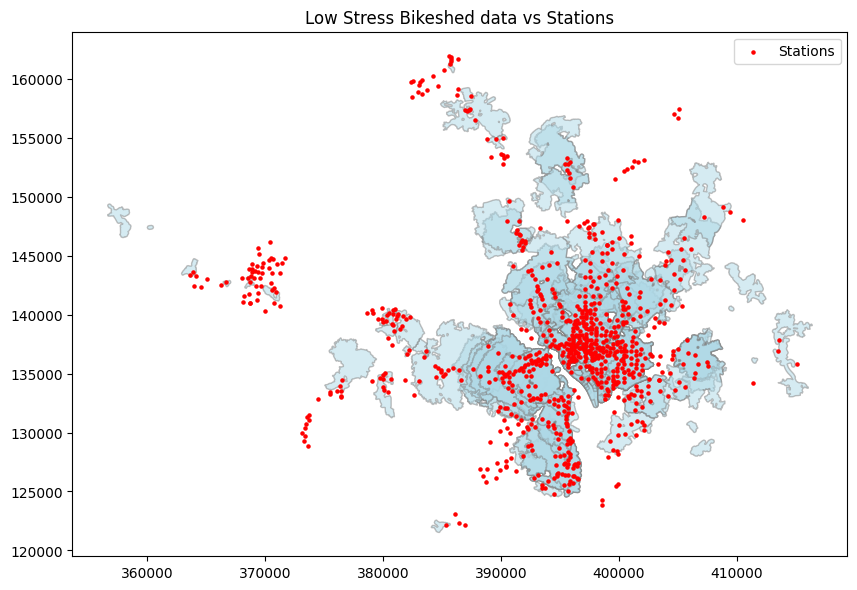

In [20]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

low_stress_bikeshed.plot(ax=ax, color="lightblue", edgecolor="gray", alpha=0.5, label="Built Env")
stations_gpd.plot(ax=ax, color="red", markersize=5, label="Stations")

plt.legend()
plt.title("Low Stress Bikeshed data vs Stations")
plt.show()

/tmp/ipykernel_25670/3744797971.py:8: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


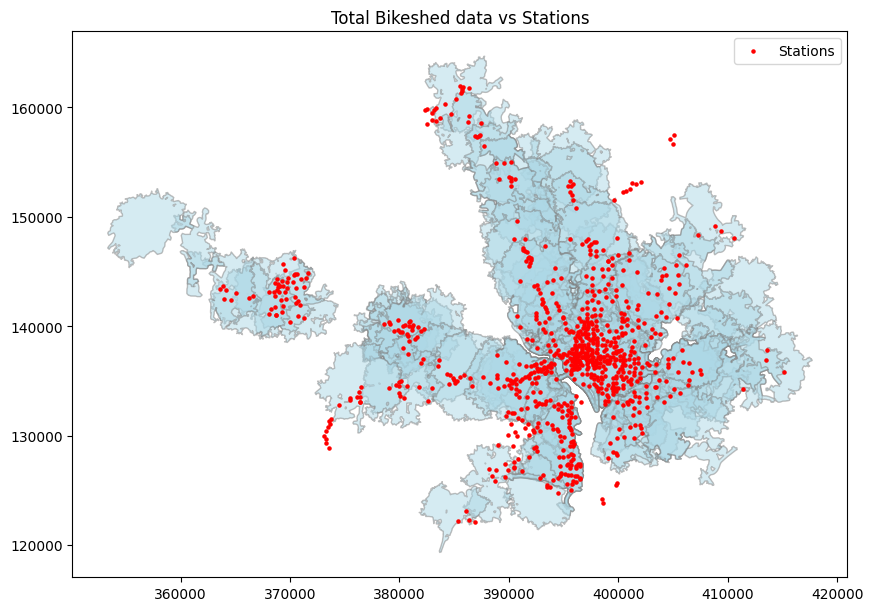

In [21]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

total_bikeshed.plot(ax=ax, color="lightblue", edgecolor="gray", alpha=0.5, label="Built Env")
stations_gpd.plot(ax=ax, color="red", markersize=5, label="Stations")

plt.legend()
plt.title("Total Bikeshed data vs Stations")
plt.show()

In [22]:
# remove index right
stations_with_census = stations_with_census.drop(columns="index_right")
#low stress
low_stress_join = gpd.sjoin(stations_with_census, low_stress_bikeshed[["geometry"]], how="left", predicate="within")
low_stress_join = low_stress_join[~low_stress_join.index.duplicated(keep="first")] # dedupe for overlapping polygons
# add indicator
stations_with_census["in_low_stress_bikeshed"] = (~low_stress_join["index_right"].isna()).astype(int)
# total
total_join = gpd.sjoin(stations_with_census, total_bikeshed[["geometry"]], how="left", predicate="within")
total_join = total_join[~total_join.index.duplicated(keep="first")] # dedupe for overlapping polygons
# add indicator
stations_with_census["in_total_bikeshed"] = (~total_join["index_right"].isna()).astype(int)  # assing 1 or 0 for if in the bikeshed

# Write out

In [23]:
stations_finished = stations_with_census.drop(columns="geometry").reset_index(drop=True)
stations_finished.to_parquet("data/stations_finished.parquet", index=False, engine="pyarrow", compression="snappy")


In [24]:
stations_finished

,station_id,station_name,latitude,longitude,TRACTCE_left,GEOID_left,m1_1_schoo,m1_2_quali,m1_3_playg,m1_4_cross,...,pop_femaleE,pop_femaleM,median_ageE,median_ageM,median_hh_incomeE,median_hh_incomeM,year,state,in_low_stress_bikeshed,in_total_bikeshed
0,31087.0,Monroe Ave & Leslie Ave,38.820932,-77.053096,NaN,NaN,NaN,NaN,NaN,NaN,...,1881.0,193.0,35.8,1.0,199444.0,32558.0,2024.0,VA,1,1
1,31283.0,14th & L St NW,38.903658,-77.031737,010100,11001010100,0.999902,0.619431,0.118688,0.112781,...,1388.0,288.0,34.5,0.7,112670.0,38301.0,2024.0,DC,1,1
2,31518.0,New York Ave & Hecht Ave NE,38.915604,-76.983683,008803,11001008803,0.999902,0.307632,0.160133,0.054962,...,2720.0,379.0,32.3,2.7,102585.0,20931.0,2024.0,DC,1,1
3,32608.0,Falls Church City Hall / Park Ave & Little Fal...,38.885434,-77.173605,NaN,NaN,NaN,NaN,NaN,NaN,...,1733.0,190.0,41.6,4.9,204183.0,26759.0,2024.0,VA,1,1
4,31104.0,Adams Mill & Columbia Rd NW,38.922925,-77.042581,003901,11001003901,0.999905,0.000000,0.999905,0.442577,...,1597.0,503.0,34.5,5.4,134922.0,57867.0,2024.0,DC,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
857,33202.0,27th St & Woodley Rd NW,38.925764,-77.055113,000501,11001000501,0.999899,0.130074,0.141519,0.017678,...,2036.0,419.0,38.5,4.1,110774.0,16937.0,2024.0,DC,1,1
858,33201.0,Kansas Ave & Blair Rd NW,38.962406,-77.010476,009505,11001009505,0.999900,0.151707,0.846429,0.146180,...,2763.0,494.0,33.8,4.0,95078.0,31875.0,2024.0,DC,1,1
859,33203.0,Howard Rd & Suitland Pkwy SE,38.865149,-77.001045,007401,11001007401,0.991277,0.000000,0.481516,0.123460,...,905.0,342.0,38.9,13.7,31862.0,14511.0,2024.0,DC,0,1
860,33204.0,15th & Chapin St NW,38.921468,-77.035244,003701,11001003701,0.999894,0.000000,0.999894,0.000000,...,1226.0,189.0,34.8,1.5,134508.0,22367.0,2024.0,DC,1,1


# Final Dataset

In [3]:
# read in the damand datast
import polars as pl
cabi_demand = pl.read_parquet("data/cabi_demand_15.parquet")
stations_finished = pl.read_parquet("data/stations_finished.parquet")
# bing bop boop bam, lets join it 
cabi_demand_finished = cabi_demand.join(stations_finished, left_on='start_station_id', right_on='station_id', how='left')

In [4]:
cabi_demand_finished

start_station_id,started_at_15,deps,arrs,demand,station_name,latitude,longitude,TRACTCE_left,GEOID_left,m1_1_schoo,m1_2_quali,m1_3_playg,m1_4_cross,m1_5_safe_,m1_6_libra,m1_7_wirel,m1_8_broad,m1_9_recre,m2_1_commu,m3_1_banks,m3_2_check,m4_1_quali,m4_2_share,m4_3_affor,m4_4_vacan,m5_1_buses,m5_2_metro,m5_3_capit,m5_4_bike_,m5_5_sidew,m5_6_parki,m6_1_groce,m6_2_low_f,m6_3_farme,m6_4_healt,m6_5_resta,…,d1_raw,d2_raw,d3_raw,d4_raw,d5_raw,d6_raw,d7_raw,d8_raw,d9_raw,STATEFP,COUNTYFP,TRACTCE_right,GEOIDFQ,GEOID_right,NAME.x,NAMELSAD,STUSPS,NAMELSADCO,STATE_NAME,LSAD,ALAND,AWATER,NAME.y,total_popE,total_popM,pop_maleE,pop_maleM,pop_femaleE,pop_femaleM,median_ageE,median_ageM,median_hh_incomeE,median_hh_incomeM,year,state,in_low_stress_bikeshed,in_total_bikeshed
f64,"datetime[μs, UTC]",i32,i32,i32,str,f64,f64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str,str,str,str,str,str,str,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,i64,i64
22907.0,2026-01-15 17:00:00 UTC,1,1,0,"""3035 V St""",38.918767,-76.965328,"""011100""","""11001011100""",0.817486,0.0,0.360518,0.040651,0.0,0.322176,0.85939,0.808346,0.73043,0.737736,0.771276,0.381927,0.065775,0.153281,0.153771,0.817414,0.202418,0.0,0.231607,0.005958,0.993762,0.914916,0.477518,0.210532,0.060055,0.564849,0.36368,…,0.194061,0.296117,0.453883,0.551066,0.260769,0.237817,0.171117,0.443689,0.379757,"""11""","""001""","""011100""","""1400000US11001011100""","""11001011100""","""111""","""Census Tract 111""","""DC""","""District of Columbia""","""District of Columbia""","""CT""",5.718692e6,366232.0,"""Census Tract 111; District of …",5028.0,733.0,2653.0,542.0,2375.0,374.0,41.9,3.0,80536.0,48056.0,2024.0,"""DC""",0,1
22907.0,2026-01-15 17:15:00 UTC,2,2,0,"""3035 V St""",38.918767,-76.965328,"""011100""","""11001011100""",0.817486,0.0,0.360518,0.040651,0.0,0.322176,0.85939,0.808346,0.73043,0.737736,0.771276,0.381927,0.065775,0.153281,0.153771,0.817414,0.202418,0.0,0.231607,0.005958,0.993762,0.914916,0.477518,0.210532,0.060055,0.564849,0.36368,…,0.194061,0.296117,0.453883,0.551066,0.260769,0.237817,0.171117,0.443689,0.379757,"""11""","""001""","""011100""","""1400000US11001011100""","""11001011100""","""111""","""Census Tract 111""","""DC""","""District of Columbia""","""District of Columbia""","""CT""",5.718692e6,366232.0,"""Census Tract 111; District of …",5028.0,733.0,2653.0,542.0,2375.0,374.0,41.9,3.0,80536.0,48056.0,2024.0,"""DC""",0,1
22907.0,2026-01-15 17:45:00 UTC,2,2,0,"""3035 V St""",38.918767,-76.965328,"""011100""","""11001011100""",0.817486,0.0,0.360518,0.040651,0.0,0.322176,0.85939,0.808346,0.73043,0.737736,0.771276,0.381927,0.065775,0.153281,0.153771,0.817414,0.202418,0.0,0.231607,0.005958,0.993762,0.914916,0.477518,0.210532,0.060055,0.564849,0.36368,…,0.194061,0.296117,0.453883,0.551066,0.260769,0.237817,0.171117,0.443689,0.379757,"""11""","""001""","""011100""","""1400000US11001011100""","""11001011100""","""111""","""Census Tract 111""","""DC""","""District of Columbia""","""District of Columbia""","""CT""",5.718692e6,366232.0,"""Census Tract 111; District of …",5028.0,733.0,2653.0,542.0,2375.0,374.0,41.9,3.0,80536.0,48056.0,2024.0,"""DC""",0,1
22907.0,2026-01-15 18:00:00 UTC,1,1,0,"""3035 V St""",38.918767,-76.965328,"""011100""","""11001011100""",0.817486,0.0,0.360518,0.040651,0.0,0.322176,0.85939,0.808346,0.73043,0.737736,0.771276,0.381927,0.065775,0.153281,0.153771,0.817414,0.202418,0.0,0.231607,0.005958,0.993762,0.914916,0.477518,0.210532,0.060055,0.564849,0.36368,…,0.194061,0.296117,0.453883,0.551066,0.260769,0.237817,0.171117,0.443689,0.379757,"""11""","""001""","""011100""","""1400000US11001011100""","""11001011100""","""111""","""Census Tract 111""","""DC""","""District of Columbia""","""District of Columbia""","""CT""",5.718692e6,366232.0,"""Census Tract 111; District of …",5028.0,733.0,2653.0,542.0,2375.0,374.0,41.9,3.0,80536.0,48056

In [5]:
cabi_demand_finished.write_parquet("data/cabi_demand_with_stations.parquet")